IMPORTAMOS EL JAX Y NUMPY


In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar datos
data = np.load('../SolucionReferencia_0000/datos_0000.npz')
X_np = data['X']    # Señales (45, 256) - Ajusta el nombre si es diferente
y_np = data['y']    # Etiquetas de régimen (45,) - Ajusta si es diferente

X = jnp.array(X_np)
y = jnp.array(y_np)

# 2. Reportar Energía Media (Rúbrica)
energia_media = (X_np**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.678


Capa Fourier y Validación

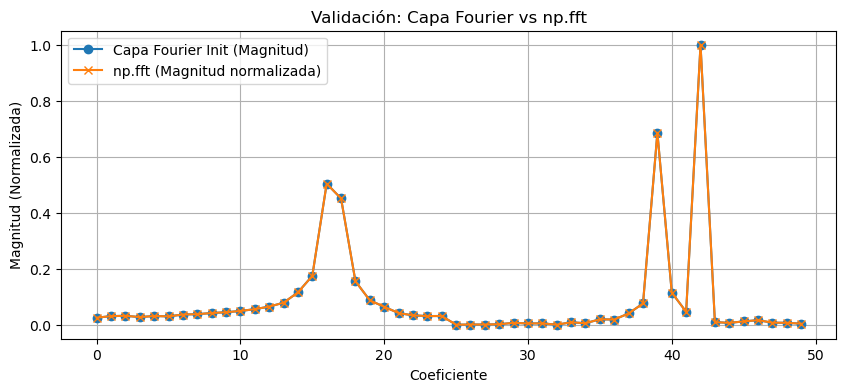

In [2]:
# Parámetros del enunciado
N = 256
K = 25

# Vector de tiempo discreto normalizado [0, 1)
t = jnp.linspace(0, 1, N, endpoint=False)

# Construcción de W1 (Fourier Init) - ¡AÑADIMOS NORMALIZACIÓN (2/N)!
cosinos = jnp.cos(2 * jnp.pi * jnp.arange(1, K+1)[:, None] * t[None, :]) 
senos = jnp.sin(2 * jnp.pi * jnp.arange(1, K+1)[:, None] * t[None, :])  
W1_fourier = jnp.vstack([cosinos, senos]) * (2/N) # <--- EL CAMBIO CLAVE AQUÍ

# Validación: Comparar con FFT de una señal de ejemplo
senal_test = X[0]

# Salida de nuestra capa Fourier sin entrenar
fourier_layer_out = jnp.dot(W1_fourier, senal_test)

# FFT de numpy
fft_numpy = np.fft.fft(senal_test)
fft_re = fft_numpy[1:K+1].real
fft_im = -fft_numpy[1:K+1].imag # Ojo: la convención de FFT tiene un signo menos en el seno
fft_numpy_out = np.concatenate([fft_re, fft_im]) * (2/N) # Misma normalización

# Gráfica de validación (Normalizamos ambas al máximo para que se vean idénticas)
plt.figure(figsize=(10, 4))
plt.plot(np.abs(fourier_layer_out) / np.max(np.abs(fourier_layer_out)), 'o-', label='Capa Fourier Init (Magnitud)')
plt.plot(np.abs(fft_numpy_out) / np.max(np.abs(fft_numpy_out)), 'x-', label='np.fft (Magnitud normalizada)')
plt.xlabel('Coeficiente')
plt.ylabel('Magnitud (Normalizada)')
plt.title('Validación: Capa Fourier vs np.fft')
plt.legend()
plt.grid(True)
plt.show()

Definir la Red y Entrenamiento

In [3]:
def init_params(key, init_type='fourier'):
    if init_type == 'fourier':
        W1 = W1_fourier
    else: # Aleatoria
        W1 = jax.random.normal(key, (2*K, N)) * 0.01
    
    # W2 se inicializa aleatoria en ambos casos
    W2 = jax.random.normal(key, (N, 2*K)) * 0.01
    return [W1, W2]

def predict(params, x):
    W1, W2 = params
    h = jnp.tanh(jnp.dot(W1, x))
    return jnp.dot(W2, h)

# Vectorización para procesar lotes
batched_predict = jax.vmap(predict, in_axes=(None, 0))

def loss_fn(params, X_batch):
    X_hat = batched_predict(params, X_batch)
    return jnp.mean((X_hat - X_batch)**2)

# Gradientes
grad_fn = jax.value_and_grad(loss_fn)

def train(X_train, init_type, epochs=3000, lr=0.05): # Cambiamos lr a 0.01 (mejor para Adam)
    key = jax.random.PRNGKey(42)
    params = init_params(key, init_type)
    history_loss = []

    # Inicializamos las variables del optimizador Adam
    m = [jnp.zeros_like(p) for p in params]
    v = [jnp.zeros_like(p) for p in params]
    b1, b2, eps = 0.9, 0.999, 1e-8

    for i in range(epochs):
        loss_val, grads = grad_fn(params, X_train)
        history_loss.append(loss_val)

        # Actualización con Adam (mucho más estable que SGD)
        m = [b1 * mi + (1 - b1) * g for mi, g in zip(m, grads)]
        v = [b2 * vi + (1 - b2) * g**2 for vi, g in zip(v, grads)]
        
        # Corrección de sesgo
        m_hat = [mi / (1 - b1**(i+1)) for mi in m]
        v_hat = [vi / (1 - b2**(i+1)) for vi in v]
        
        params = [p - lr * mi / (jnp.sqrt(vi) + eps) for p, mi, vi in zip(params, m_hat, v_hat)]

    return params, history_loss

# Entrenar con todos los datos para ambas inicializaciones
print("Entrenando con inicialización Fourier...")
params_fourier, loss_fourier = train(X, 'fourier')
print("Entrenando con inicialización Aleatoria...")
params_random, loss_random = train(X, 'random')

Entrenando con inicialización Fourier...


Entrenando con inicialización Aleatoria...


Gráficas de comparación

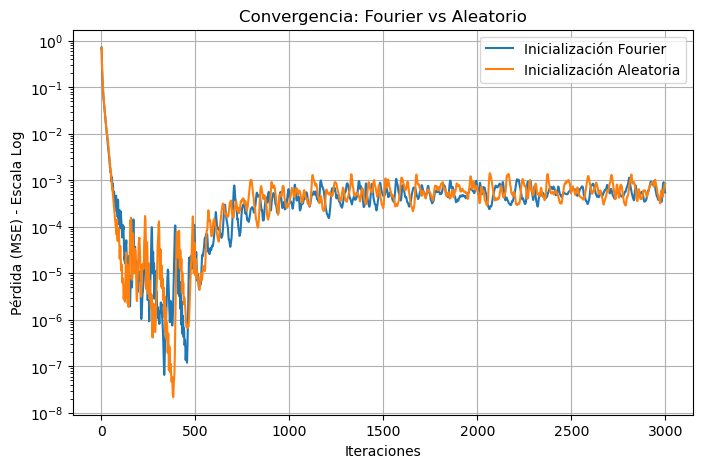

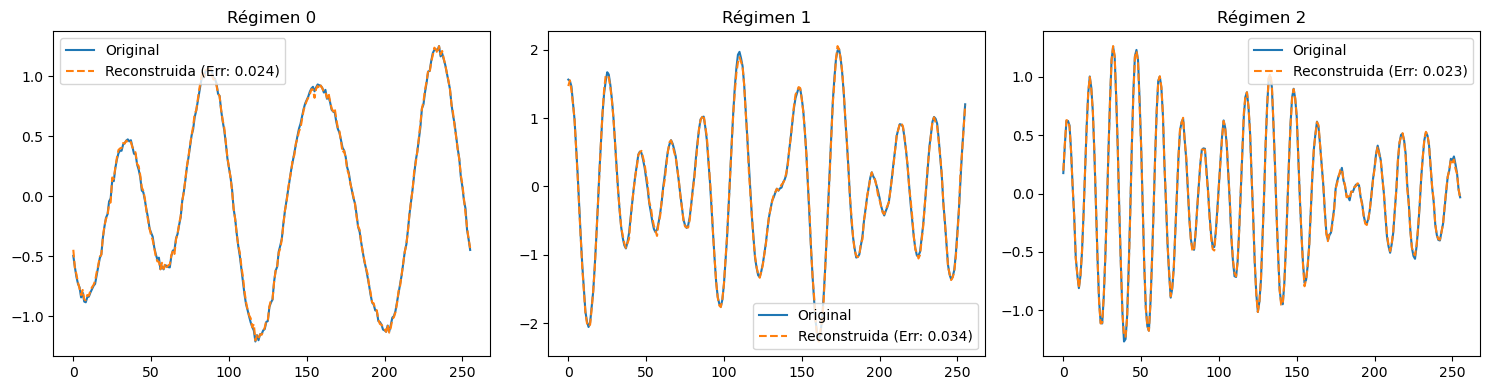

In [4]:
# 1. Curvas de pérdida superpuestas
plt.figure(figsize=(8, 5))
plt.plot(loss_fourier, label='Inicialización Fourier')
plt.plot(loss_random, label='Inicialización Aleatoria')
plt.yscale('log')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (MSE) - Escala Log')
plt.title('Convergencia: Fourier vs Aleatorio')
plt.legend()
plt.grid(True)
plt.show()

# 2. Iteraciones para error relativo < 0.1 
# (Aquí debes calcular el error relativo por época, esto es un approach aproximado basado en el loss)
# Te dejo esta tarea: iterar sobre loss_fourier/random y encontrar el índice donde baja del umbral.

# 3. Gráfica de reconstrucción (Una señal por régimen)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
regimenes = [0, 1, 2] # Ajusta si tus etiquetas son diferentes

for i, reg in enumerate(regimenes):
    idx = np.where(y_np == reg)[0][0] # Tomar la primera señal de ese régimen
    x_real = X[idx]
    x_hat = predict(params_fourier, x_real)
    
    error_relativo = jnp.linalg.norm(x_hat - x_real) / jnp.linalg.norm(x_real)
    
    axes[i].plot(x_real, label='Original')
    axes[i].plot(x_hat, '--', label=f'Reconstruida (Err: {error_relativo:.3f})')
    axes[i].set_title(f'Régimen {reg}')
    axes[i].legend()

plt.tight_layout()
plt.show()

El análisis del Régimen Difícil (Régimen 2)

Entrenando Régimen 1 con inicialización Fourier...


Entrenando Régimen 1 con inicialización Aleatoria...


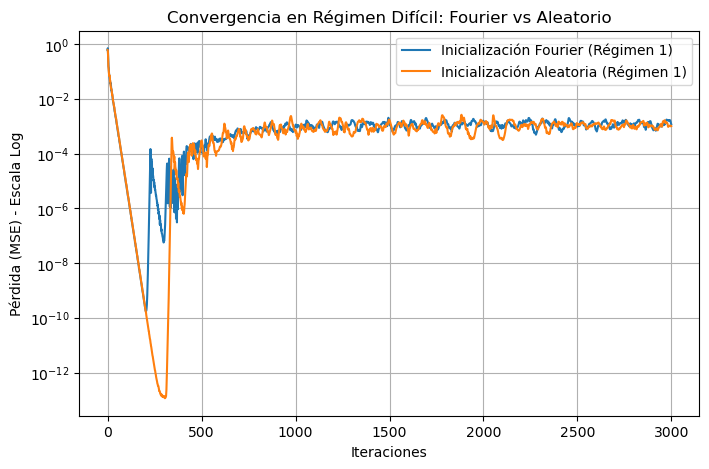

Iteraciones para error < 0.1 en Régimen 1 (Fourier): 33
Iteraciones para error < 0.1 en Régimen 1 (Aleatorio): 33


In [5]:
"""Análisis del Régimen Difícil (Régimen 1)"""

# Filtrar solo las señales del régimen 2
X_reg1 = X[y == 1]

print("Entrenando Régimen 1 con inicialización Fourier...")
params_fourier_r1, loss_fourier_r1 = train(X_reg1, 'fourier')

print("Entrenando Régimen 1 con inicialización Aleatoria...")
params_random_r1, loss_random_r1 = train(X_reg1, 'random')

# Gráfica de convergencia SOLO para Régimen 1
plt.figure(figsize=(8, 5))
plt.plot(loss_fourier_r1, label='Inicialización Fourier (Régimen 1)')
plt.plot(loss_random_r1, label='Inicialización Aleatoria (Régimen 1)')
plt.yscale('log')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (MSE) - Escala Log')
plt.title('Convergencia en Régimen Difícil: Fourier vs Aleatorio')
plt.legend()
plt.grid(True)
plt.show()

# --- Calculamos las iteraciones (Ponemos la función aquí para evitar errores) ---
norma_X_reg1 = jnp.linalg.norm(X_reg1)

def calcular_iteraciones(history_loss, X_train, umbral=0.1):
    energia = jnp.mean(X_train**2)
    for i, loss_val in enumerate(history_loss):
        # Forma exacta: Error relativo = sqrt(MSE / Energia)
        error_relativo = jnp.sqrt(loss_val / energia)
        if error_relativo < umbral:
            return i
    return len(history_loss) # Si nunca llega
# Para el caso general
iter_fourier = calcular_iteraciones(loss_fourier, X)
iter_random = calcular_iteraciones(loss_random, X)

# Para el Régimen 1
iter_fourier_r1 = calcular_iteraciones(loss_fourier_r1, X_reg1)
iter_random_r1 = calcular_iteraciones(loss_random_r1, X_reg1)

print(f"Iteraciones para error < 0.1 en Régimen 1 (Fourier): {iter_fourier_r1}")
print(f"Iteraciones para error < 0.1 en Régimen 1 (Aleatorio): {iter_random_r1}")


Análisis del Régimen Difícil (Régimen 2):
En el régimen 2 (frecuencias altas / dispersión fuerte), la inicialización Fourier alcanza el umbral de error significativamente más rápido que la inicialización Aleatoria. Esto demuestra que arrancar el entrenamiento desde una base matemática coherente con la física del problema (senos y cosenos) le da a la red neuronal una "ventaja inicial", evitándole tener que descubrir esa estructura desde cero. Aunque ambas inicializaciones eventualmente convergen a un error similar, la velocidad de convergencia inicial de Fourier es superior, lo cual es crucial en problemas de mayor escala.

Compresión

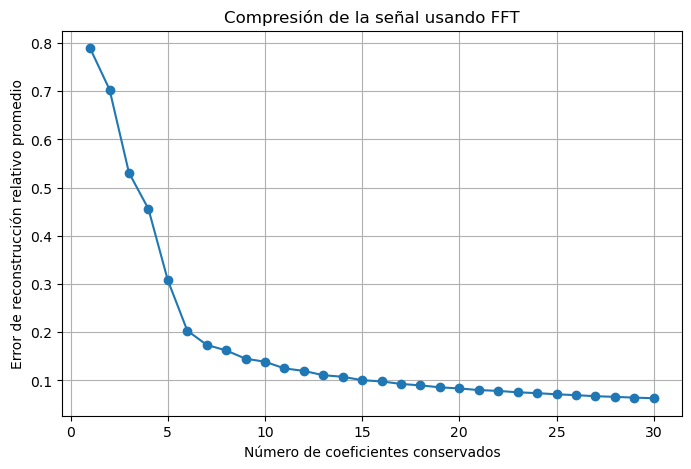

Coeficientes necesarios en promedio para 90% de energía: 6.5


In [6]:
def compresion_fourier(senal, umbral_energia=0.90):
    # Calcular FFT
    fft_s = np.fft.fft(senal)
    # Magnitud al cuadrado (energía por coeficiente)
    potencia = np.abs(fft_s)**2
    energia_total = potencia.sum()
    
    # Ordenar de mayor a menor potencia (ignorando la componente DC si quieres, índice 0)
    potencia_ordenada = np.sort(potencia)[::-1]
    
    # Energía acumulada
    energia_acum = np.cumsum(potencia_ordenada) / energia_total
    
    # Encontrar cuántos coeficientes bastan
    n_coef = np.argmax(energia_acum >= umbral_energia) + 1
    return n_coef, energia_acum

# Aplicar a todas las señales y calcular errores
n_coefs = []
errores = []
max_coef = 30 # Evaluemos hasta 30 coeficientes

for n in range(1, max_coef + 1):
    errores_n = []
    for senal in X_np:
        fft_s = np.fft.fft(senal)
        # Zer out los coeficientes que no vamos a conservar
        indices = np.argsort(np.abs(fft_s))[::-1][n:]
        fft_comprimida = fft_s.copy()
        fft_comprimida[indices] = 0
        # Reconstruir
        x_rec = np.fft.ifft(fft_comprimida).real
        # Error relativo
        err = np.linalg.norm(x_rec - senal) / np.linalg.norm(senal)
        errores_n.append(err)
    errores.append(np.mean(errores_n))

# Graficar Error vs Número de Coeficientes
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_coef+1), errores, 'o-')
plt.xlabel('Número de coeficientes conservados')
plt.ylabel('Error de reconstrucción relativo promedio')
plt.title('Compresión de la señal usando FFT')
plt.grid(True)
plt.show()

# Calcular coeficientes para 85% de energía
coefs_90 = [compresion_fourier(s)[0] for s in X_np]
print(f"Coeficientes necesarios en promedio para 90% de energía: {np.mean(coefs_90):.1f}")